<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/2435945_Ankush_Sharma_Guragai_NlP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3 NLP: News Headline Classification using RNN, LSTM with pretrained Google News Word2Vec embedding

This notebook implements an end-to-end NLP text classification pipeline.  
The dataset contains news headlines and category labels. The main aim is to classify each headline into the correct news category using sequence-based deep learning models.

**Models implemented**
1. Simple RNN with trainable embedding  
2. LSTM with trainable embedding  
3. LSTM with pretrained word embedding  

The notebook also includes preprocessing, tokenization, percentile-based padding, model comparison, error analysis, and a simple real-time prediction interface.

## Cell 2: Import Libraries

All required libraries are imported here. The code uses Keras for model building, sklearn for evaluation, and NLTK for text cleaning.

In [ ]:
import os
import re
import time
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import contractions
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalMaxPooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import gensim.downloader as api

I0000 00:00:1778397581.351850    2147 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778397582.417399    2147 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778397585.882564    2147 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Cell 3: Reproducibility Setup

A fixed seed is used so that the train-test split and model training are more consistent between runs.

In [ ]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 4: Project Configuration

Change `DATA_PATH` according to your own file location.  
The notebook saves models, figures, reports, tokenizer, and label encoder inside the results folder.

In [ ]:
DATA_PATH = "news_category.csv"

RESULTS_DIR = "task3_nlp_outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)

TEXT_COLUMN = "headline"
LABEL_COLUMN = "category"

MAX_WORDS = 15000
EMBED_DIM_TRAINABLE = 100
BATCH_SIZE = 64
EPOCHS = 20
PADDING_PERCENTILE = 95

## Cell 5: Load Dataset

The dataset is loaded using Pandas. The code also checks the available columns before selecting the text and label columns.

In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (11025, 2)
Columns: ['headline', 'category']


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


## Cell 6: Select Text and Label Columns

Only the headline and category columns are required for this classification task.  
Rows with missing text or label values are removed.

In [ ]:
# Basic safety check in case column names contain spaces or different cases
df.columns = [col.strip() for col in df.columns]

if TEXT_COLUMN not in df.columns or LABEL_COLUMN not in df.columns:
    raise ValueError(f"Required columns not found. Available columns are: {df.columns.tolist()}")

data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data = data.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
data[TEXT_COLUMN] = data[TEXT_COLUMN].astype(str)
data[LABEL_COLUMN] = data[LABEL_COLUMN].astype(str)

print("Final selected shape:", data.shape)
data.head()

Final selected shape: (11025, 2)


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


## Cell 7: Dataset Understanding

This section checks the number of text samples, number of classes, class distribution, and duplicate rows.

Total number of headlines: 11025
Number of classes: 5

Class names:
['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']

Missing values:
headline    0
category    0
dtype: int64

Duplicate rows: 78


,count
category,
SPORTS,5077
TECH,2104
MONEY,1756
CULTURE & ARTS,1074
EDUCATION,1014


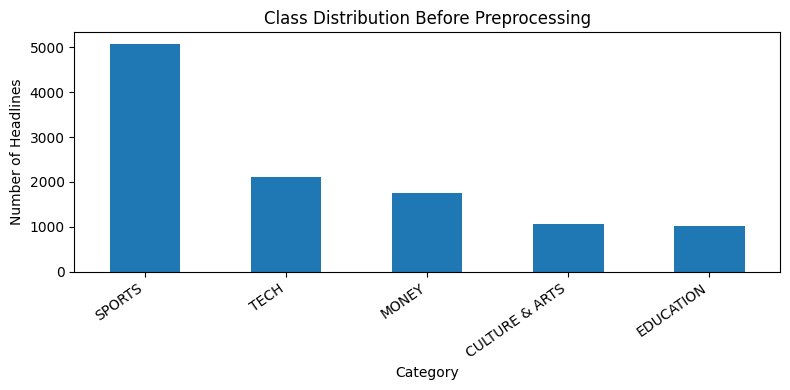

In [ ]:
print("Total number of headlines:", len(data))
print("Number of classes:", data[LABEL_COLUMN].nunique())
print("\nClass names:")
print(sorted(data[LABEL_COLUMN].unique()))

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

class_counts = data[LABEL_COLUMN].value_counts()
display(class_counts.to_frame("count"))

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution Before Preprocessing")
plt.xlabel("Category")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "class_distribution_raw.png"), dpi=150)
plt.show()

In [ ]:
# Cell: Remove Duplicate Rows

before_duplicates = len(data)

data = data.drop_duplicates(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)

after_duplicates = len(data)

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before duplicate removal: 11025
Rows after duplicate removal: 10947
Duplicates removed: 78


## Cell 8: Headline Length Analysis

Headline length is checked because it helps decide a suitable padding length later.

       raw_word_count  raw_char_count
count    10947.000000    10947.000000
mean         9.781858       59.822965
std          2.998280       18.713299
min          1.000000        3.000000
25%          8.000000       47.000000
50%         10.000000       61.000000
75%         12.000000       71.000000
max         28.000000      172.000000


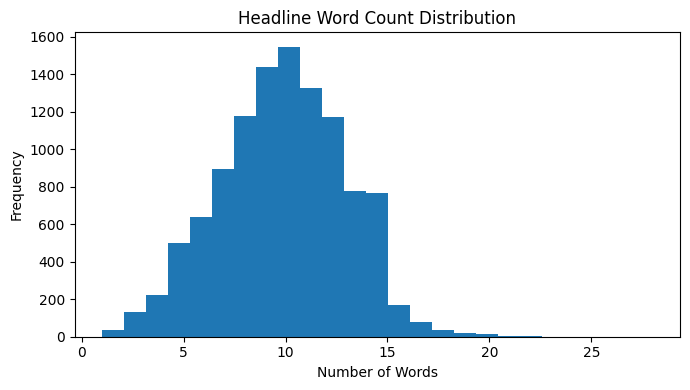

In [ ]:
data["raw_word_count"] = data[TEXT_COLUMN].apply(lambda x: len(x.split()))
data["raw_char_count"] = data[TEXT_COLUMN].apply(len)

print(data[["raw_word_count", "raw_char_count"]].describe())

plt.figure(figsize=(7, 4))
plt.hist(data["raw_word_count"], bins=25)
plt.title("Headline Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "headline_word_count_distribution.png"), dpi=150)
plt.show()

## Cell 9: Display Sample Headlines

A few examples from each category are displayed to understand the type of text in the dataset.

In [ ]:
for category in sorted(data[LABEL_COLUMN].unique()):
    print("\n" + "=" * 80)
    print("CATEGORY:", category)
    print("=" * 80)
    examples = data[data[LABEL_COLUMN] == category][TEXT_COLUMN].head(3).tolist()
    for i, example in enumerate(examples, start=1):
        print(f"{i}. {example}")


CATEGORY: CULTURE & ARTS
1. How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
2. 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
3. Meet Alex Aster, The TikToker Changing The Publishing Industry For The Better

CATEGORY: EDUCATION
1. Cyberattack Prompts Los Angeles School District To Shut Down Its Computer Systems
2. Minneapolis Teacher Contract Race Language Ignites Firestorm
3. Despite GOP Attacks, Parents Are Pretty Happy With Their Kids' Schools, Poll Finds

CATEGORY: MONEY
1. Why You Should Get Your Holiday Shopping Done ASAP
2. Investors Who Made Money Trading GameStop Have A Big Tax Bill In Store
3. The IRS Delayed Tax Season. Here's How To Get Your Refund On Time.

CATEGORY: SPORTS
1. Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
2. Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
3. Boston Marathon To Make Race More Inclusive For Nonbinary Runners

CATEGORY: TECH
1. Twitch Bans Gambling Sites After Strea

## Cell 10: Download NLTK Resources

Stopwords and lemmatization resources are required for text preprocessing.

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Keep some negation words because they can change meaning in text classification
for neg_word in ["not", "no", "nor"]:
    stop_words.discard(neg_word)

[nltk_data] Downloading package stopwords to /home/ankush/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ankush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ankush/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Cell 11: Text Cleaning Function

The cleaning function applies the required preprocessing steps:
- lowercasing  
- contraction expansion  
- URL removal  
- mention and hashtag removal  
- number and special character removal  
- stopword removal  
- lemmatization

In [ ]:
def clean_headline(text):
    text = str(text).lower()
    text = contractions.fix(text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 1:
            tokens.append(lemmatizer.lemmatize(word))

    return " ".join(tokens)

## Cell 12: Apply Text Cleaning

The cleaned text is stored in a new column. Empty cleaned rows are removed because they do not provide useful input to the model.

In [ ]:
data["clean_text"] = data[TEXT_COLUMN].apply(clean_headline)

before_empty_removal = len(data)
data = data[data["clean_text"].str.strip() != ""].reset_index(drop=True)
after_empty_removal = len(data)

print("Rows before empty-text removal:", before_empty_removal)
print("Rows after empty-text removal:", after_empty_removal)

data[[TEXT_COLUMN, "clean_text", LABEL_COLUMN]].head(10)

Rows before empty-text removal: 10947
Rows after empty-text removal: 10947


,headline,clean_text,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever not navel gazey look inside tv r...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base stealing shortstop dodger dy,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...,SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",meet alex aster tiktoker changing publishing i...,CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,tiktok search result riddled misinformation re...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,boston marathon make race inclusive nonbinary ...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",anthony varvaro mlb pitcher turned transit cop...,SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,ani liu brilliantly disguising art science,CULTURE & ARTS


## Cell 13: Cleaned Text Visualization

The most frequent words and a word cloud are used to understand common vocabulary after preprocessing.

,frequency
not,653
video,481
new,457
photo,452
game,366
nfl,363
world,318
player,310
school,286
win,271


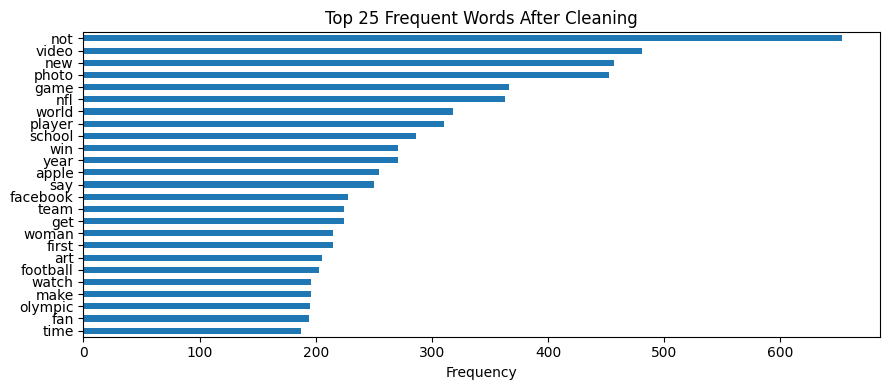

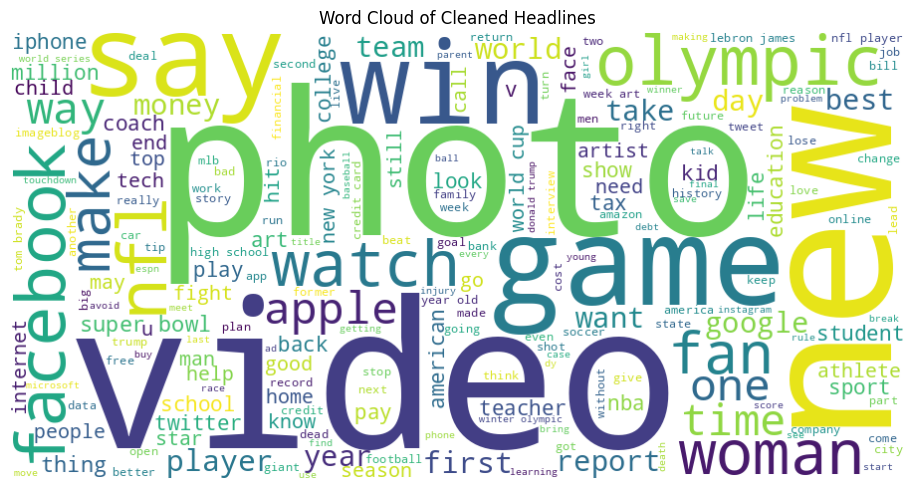

In [ ]:
all_words = " ".join(data["clean_text"]).split()
word_freq = pd.Series(all_words).value_counts().head(25)

display(word_freq.to_frame("frequency"))

plt.figure(figsize=(9, 4))
word_freq.sort_values().plot(kind="barh")
plt.title("Top 25 Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "top_25_clean_words.png"), dpi=150)
plt.show()

wordcloud_text = " ".join(data["clean_text"])
wc = WordCloud(width=900, height=450, background_color="white").generate(wordcloud_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Headlines")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "wordcloud_cleaned_headlines.png"), dpi=150)
plt.show()

## Cell 14: Encode Labels and Split Dataset

The dataset is split into 80% training and 20% testing.  
A small validation set is also created from the training data to monitor model learning during training.

In [ ]:
label_encoder = LabelEncoder()
data["label_id"] = label_encoder.fit_transform(data[LABEL_COLUMN])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

X = data["clean_text"].values
y = data["label_id"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train
)

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))
print("Testing samples:", len(X_test_text))
print("Classes:", class_names)

Training samples: 7881
Validation samples: 876
Testing samples: 2190
Classes: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']


## Cell 15: Tokenization and Percentile-Based Padding

Keras Tokenizer converts words into integer sequences.  
The padding length is selected using the 95th percentile of training sequence lengths so that very long headlines do not unnecessarily increase computation.

In [ ]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
val_sequences = tokenizer.texts_to_sequences(X_val_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(sequence_lengths, PADDING_PERCENTILE))
MAX_LEN = max(MAX_LEN, 5)

print("95th percentile padding length:", MAX_LEN)
print("Longest training sequence:", max(sequence_lengths))

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_val = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

actual_vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", actual_vocab_size)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

95th percentile padding length: 11
Longest training sequence: 17
Vocabulary size used: 10712
X_train shape: (7881, 11)
X_val shape: (876, 11)
X_test shape: (2190, 11)


## Cell 16: Class Weight Calculation

The dataset is imbalanced, so class weights are used during training.  
This helps the model avoid becoming biased toward the majority class.

In [ ]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: weight for i, weight in enumerate(class_weight_values)}

print("Class weights:")
for idx, weight in class_weights.items():
    print(f"{class_names[idx]}: {weight:.4f}")

Class weights:
CULTURE & ARTS: 2.0767
EDUCATION: 2.1592
MONEY: 1.2490
SPORTS: 0.4312
TECH: 1.0686


## Cell 17: Training and Evaluation Helper Functions

These functions keep the notebook cleaner and make all models evaluated in the same way.

In [ ]:
def get_callbacks(model_tag):
    checkpoint_path = os.path.join(RESULTS_DIR, f"{model_tag}_best.keras")

    return [
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]


def plot_training_curves(history, model_name):
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(os.path.join(RESULTS_DIR, f"{model_name}_history.csv"), index=False)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name}_loss_curve.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name}_accuracy_curve.png"), dpi=150)
    plt.show()


def evaluate_model(model, model_name):
    probabilities = model.predict(X_test, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    acc = accuracy_score(y_test, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("-" * 60)
    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"Weighted F1   : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(7, 6))
    disp.plot(cmap=None, xticks_rotation=35, values_format="d")
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name}_confusion_matrix.png"), dpi=150)
    plt.show()

    report = classification_report(
        y_test,
        predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    pd.DataFrame(report).transpose().to_csv(
        os.path.join(RESULTS_DIR, f"{model_name}_classification_report.csv")
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": f1
    }, predictions


def train_model(model, model_name):
    print(model.summary())

    start = time.time()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    training_time = time.time() - start

    plot_training_curves(history, model_name)

    result, predictions = evaluate_model(model, model_name)
    result["Training Time (seconds)"] = training_time

    print(f"{model_name} training time: {training_time:.2f} seconds")

    return model, history, result, predictions

## Cell 18: Model 1 — Simple RNN with Trainable Embedding

This model uses a trainable embedding layer followed by a SimpleRNN layer.  
It is the simplest recurrent model in this notebook, so it works as a baseline for sequence learning.

In [ ]:
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=actual_vocab_size, output_dim=EMBED_DIM_TRAINABLE),
    SimpleRNN(64, dropout=0.25, recurrent_dropout=0.10),
    BatchNormalization(),
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.40),
    Dense(num_classes, activation="softmax")
])

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

I0000 00:00:1778397638.540953    2147 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### Short Architecture Note: Simple RNN

The embedding layer learns word representations directly from the training set.  
The SimpleRNN layer reads the headline as a word sequence, but it can struggle with longer dependencies.  
Dropout and L2 regularization are included to reduce overfitting.

## Cell 19: Train and Evaluate Model 1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 100)        │     1,071,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,086,501 (4.14 MB)

 Trainable params: 1,086,373 (4.14 MB)

 Non-trainable params: 128 (512.00 B)

...

122/124 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2729 - loss: 1.9007

I0000 00:00:1778397655.330866    2818 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_2056_grad_2403_const_0__.31.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778397655.331080    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3104__.35


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2735 - loss: 1.8982

I0000 00:00:1778397660.350866    2819 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778397660.977731    2819 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778397662.736271    2820 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778397663.432915    3168 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul


Epoch 1: val_accuracy improved from None to 0.55936, saving model to task3_nlp_outputs/model_1_simple_rnn_best.keras

Epoch 1: finished saving model to task3_nlp_outputs/model_1_simple_rnn_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.3063 - loss: 1.7465 - val_accuracy: 0.5594 - val_loss: 1.3870 - learning_rate: 0.0010
Epoch 2/20
120/124 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5302 - loss: 1.2554
Epoch 2: val_accuracy improved from 0.55936 to 0.76484, saving model to task3_nlp_outputs/model_1_simple_rnn_best.keras

Epoch 2: finished saving model to task3_nlp_outputs/model_1_simple_rnn_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5926 - loss: 1.1216 - val_accuracy: 0.7648 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 3/20
121/124 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7408 - loss: 0.7713
Epoch 3: val_accuracy improved from 0.76484 to 0.77626, saving model to task3_nlp_outputs/model_1_simple_rnn_best.keras

Epoch 3: finish

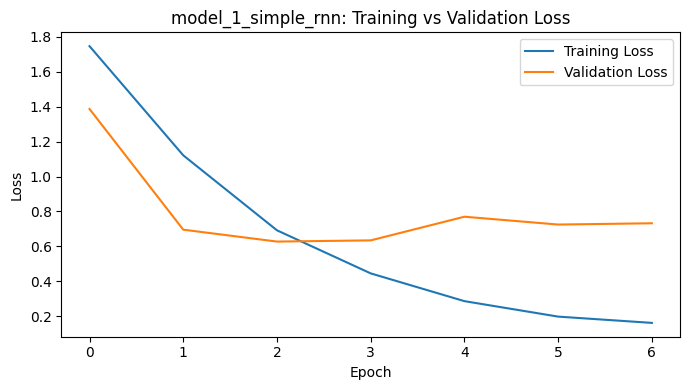

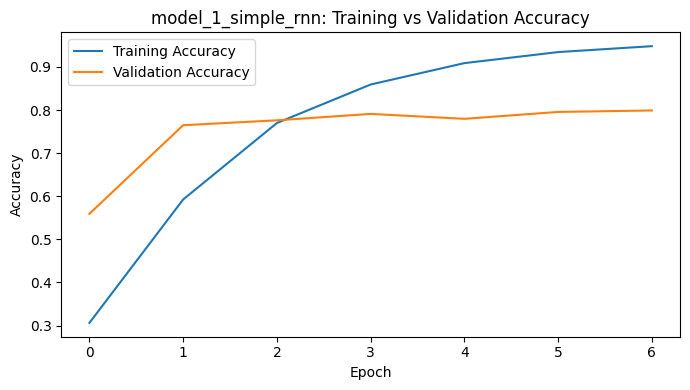


model_1_simple_rnn Evaluation
------------------------------------------------------------
Accuracy      : 0.7776
Precision     : 0.7962
Recall        : 0.7776
Weighted F1   : 0.7758

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.50      0.68      0.58       211
     EDUCATION       0.64      0.60      0.62       203
         MONEY       0.70      0.77      0.73       351
        SPORTS       0.87      0.93      0.90      1015
          TECH       0.93      0.55      0.69       410

      accuracy                           0.78      2190
     macro avg       0.73      0.71      0.70      2190
  weighted avg       0.80      0.78      0.78      2190



<Figure size 700x600 with 0 Axes>

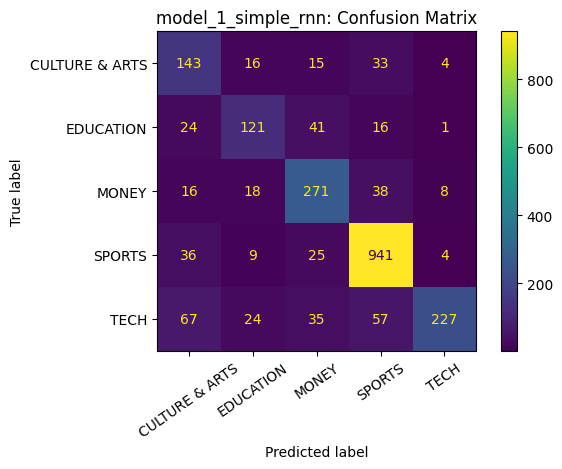

model_1_simple_rnn training time: 34.36 seconds


In [ ]:
rnn_model, rnn_history, rnn_result, rnn_predictions = train_model(
    rnn_model,
    "model_1_simple_rnn"
)

## Cell 20: Model 2 — LSTM with Trainable Embedding

The second model uses an LSTM layer instead of SimpleRNN.  
LSTM is stronger for sequence modelling because its gates help preserve useful information and reduce the vanishing gradient problem.

In [ ]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=actual_vocab_size, output_dim=EMBED_DIM_TRAINABLE),
    LSTM(96, dropout=0.25, recurrent_dropout=0.10),
    BatchNormalization(),
    Dense(96, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.45),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



### Short Architecture Note: LSTM

This model still learns embeddings from the dataset, but the recurrent layer is changed to LSTM.  
The LSTM gates help the model keep important words and reduce the weakness of standard RNNs on sequence data.

## Cell 21: Train and Evaluate Model 2

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 100)        │     1,071,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 96)             │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,157,029 (4.41 MB)

 Trainable params: 1,156,837 (4.41 MB)

 Non-trainable params: 192 (768.00 B)

None
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.3759 - loss: 1.4671
Epoch 1: val_accuracy improved from None to 0.73402, saving model to task3_nlp_outputs/model_2_lstm_trainable_embedding_best.keras

Epoch 1: finished saving model to task3_nlp_outputs/model_2_lstm_trainable_embedding_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.5389 - loss: 1.1959 - val_accuracy: 0.7340 - val_loss: 1.2568 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8406 - loss: 0.5341
Epoch 2: val_accuracy improved from 0.73402 to 0.80594, saving model to task3_nlp_outputs/model_2_lstm_trainable_embedding_best.keras

Epoch 2: finished saving model to task3_nlp_outputs/model_2_lstm_trainable_embedding_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.8736 - loss: 0.4285 - val_accuracy: 0.8059 - val_loss: 0.8147 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9411

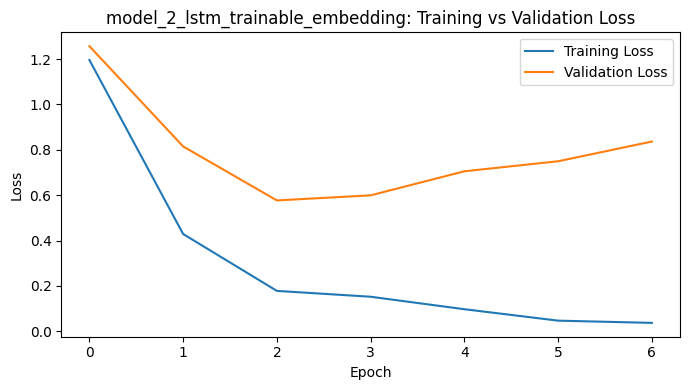

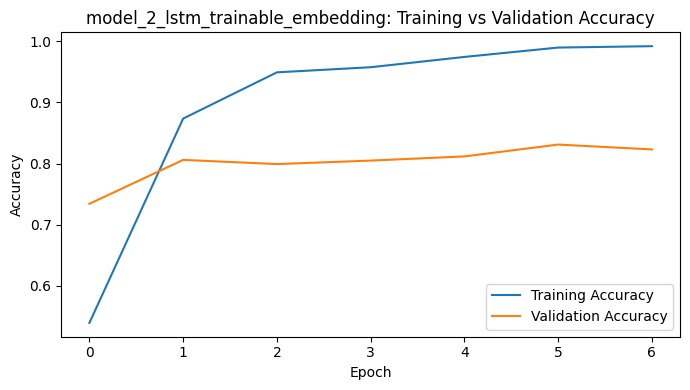


model_2_lstm_trainable_embedding Evaluation
------------------------------------------------------------
Accuracy      : 0.7973
Precision     : 0.8341
Recall        : 0.7973
Weighted F1   : 0.8010

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.46      0.88      0.60       211
     EDUCATION       0.89      0.50      0.64       203
         MONEY       0.79      0.68      0.74       351
        SPORTS       0.89      0.92      0.91      1015
          TECH       0.88      0.69      0.78       410

      accuracy                           0.80      2190
     macro avg       0.78      0.74      0.73      2190
  weighted avg       0.83      0.80      0.80      2190



<Figure size 700x600 with 0 Axes>

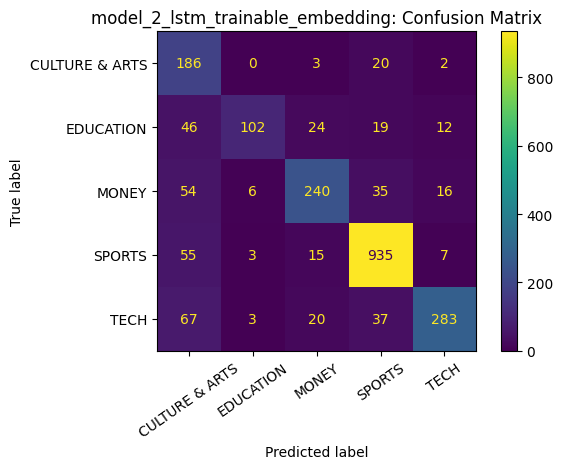

model_2_lstm_trainable_embedding training time: 155.45 seconds


In [ ]:
lstm_model, lstm_history, lstm_result, lstm_predictions = train_model(
    lstm_model,
    "model_2_lstm_trainable_embedding"
)

## Cell 22: Load Pretrained Word Embeddings

This notebook uses `word2vec-google-news-300` as the pretrained embedding source.  
It is a pretrained word-vector model available through Gensim.  



In [ ]:
# PRETRAINED_EMBEDDING_NAME = "glove-wiki-gigaword-100"
# Alternative exact Word2Vec option, but much larger:
PRETRAINED_EMBEDDING_NAME = "word2vec-google-news-300"

print("Loading pretrained embedding:", PRETRAINED_EMBEDDING_NAME)
pretrained_vectors = api.load(PRETRAINED_EMBEDDING_NAME)

PRETRAINED_DIM = pretrained_vectors.vector_size
print("Embedding dimension:", PRETRAINED_DIM)

Loading pretrained embedding: word2vec-google-news-300
Embedding dimension: 300


## Cell 23: Build Embedding Matrix

The embedding matrix connects the Keras tokenizer vocabulary with the pretrained vectors.  
Words not found in the pretrained model are kept as zero vectors.

In [ ]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((actual_vocab_size, PRETRAINED_DIM), dtype=np.float32)

matched_words = 0
for word, index in word_index.items():
    if index >= actual_vocab_size:
        continue

    if word in pretrained_vectors:
        embedding_matrix[index] = pretrained_vectors[word]
        matched_words += 1

coverage = matched_words / min(len(word_index), actual_vocab_size - 1)

print("Matched words:", matched_words)
print(f"Vocabulary coverage: {coverage:.2%}")
print("Embedding matrix shape:", embedding_matrix.shape)

Matched words: 9074
Vocabulary coverage: 84.72%
Embedding matrix shape: (10712, 300)


## Cell 24:Model 3 — LSTM with Pretrained Google News Word2Vec Embedding

The third model uses pretrained word vectors instead of learning all embeddings from zero.  
The embedding layer is frozen first so that the model uses the already learned semantic meaning of words.

In [ ]:
pretrained_lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=PRETRAINED_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(96, dropout=0.25, recurrent_dropout=0.10),
    BatchNormalization(),
    Dense(96, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.45),
    Dense(num_classes, activation="softmax")
])

pretrained_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Short Architecture Note: Pretrained Embedding LSTM

This model is similar to the previous LSTM model, but it starts with external word knowledge from pretrained vectors.  
This can improve generalization because words with similar meanings often have similar vector representations.

## Cell 25: Train and Evaluate Model 3

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 300)        │     3,213,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │       152,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,376,229 (12.88 MB)

 Trainable params: 162,437 (634.52 KB)

 Non-trainable params: 3,213,792 (12.26 MB)

None
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.4949 - loss: 1.2342
Epoch 1: val_accuracy improved from None to 0.78196, saving model to task3_nlp_outputs/model_3_lstm_word2vec_embedding_best.keras

Epoch 1: finished saving model to task3_nlp_outputs/model_3_lstm_word2vec_embedding_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 31s 145ms/step - accuracy: 0.6297 - loss: 0.9745 - val_accuracy: 0.7820 - val_loss: 1.1110 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7761 - loss: 0.6914
Epoch 2: val_accuracy improved from 0.78196 to 0.84475, saving model to task3_nlp_outputs/model_3_lstm_word2vec_embedding_best.keras

Epoch 2: finished saving model to task3_nlp_outputs/model_3_lstm_word2vec_embedding_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.7762 - loss: 0.6727 - val_accuracy: 0.8447 - val_loss: 0.7399 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8091 - l

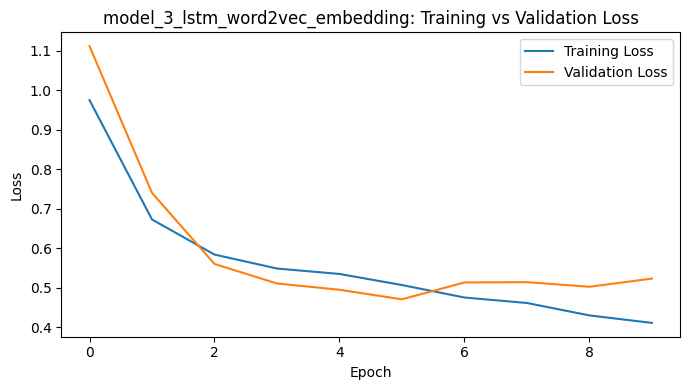

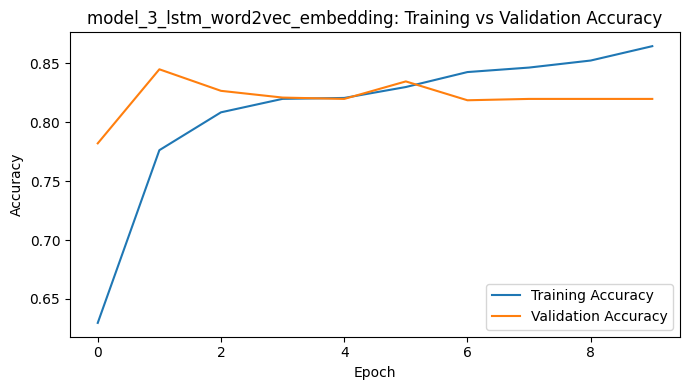


model_3_lstm_word2vec_embedding Evaluation
------------------------------------------------------------
Accuracy      : 0.8333
Precision     : 0.8431
Recall        : 0.8333
Weighted F1   : 0.8366

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.69      0.82      0.74       211
     EDUCATION       0.64      0.75      0.69       203
         MONEY       0.75      0.79      0.77       351
        SPORTS       0.95      0.89      0.92      1015
          TECH       0.82      0.77      0.80       410

      accuracy                           0.83      2190
     macro avg       0.77      0.80      0.79      2190
  weighted avg       0.84      0.83      0.84      2190



<Figure size 700x600 with 0 Axes>

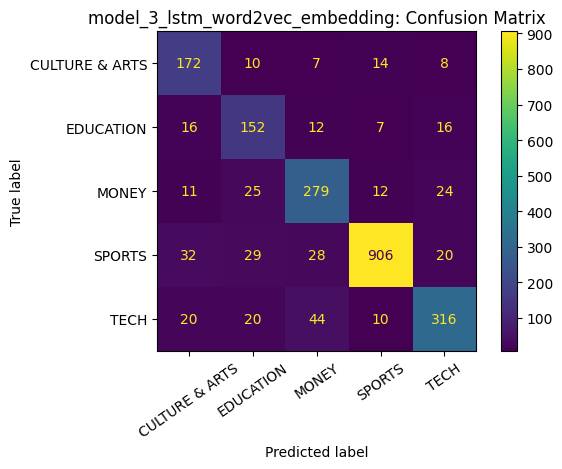

model_3_lstm_word2vec_embedding training time: 186.19 seconds


In [ ]:
pretrained_lstm_model, pretrained_history, pretrained_result, pretrained_predictions = train_model(
    pretrained_lstm_model,
    "model_3_lstm_word2vec_embedding"
)

## Cell 26: Compare All Three Models

The comparison table checks accuracy, precision, recall, weighted F1-score, and training time for all models.

,Model,Accuracy,Precision,Recall,Weighted F1,Training Time (seconds)
0,model_3_lstm_word2vec_embedding,0.833333,0.843111,0.833333,0.836586,186.194288
1,model_2_lstm_trainable_embedding,0.797260,0.834085,0.797260,0.801040,155.453630
2,model_1_simple_rnn,0.777626,0.796196,0.777626,0.775842,34.364016


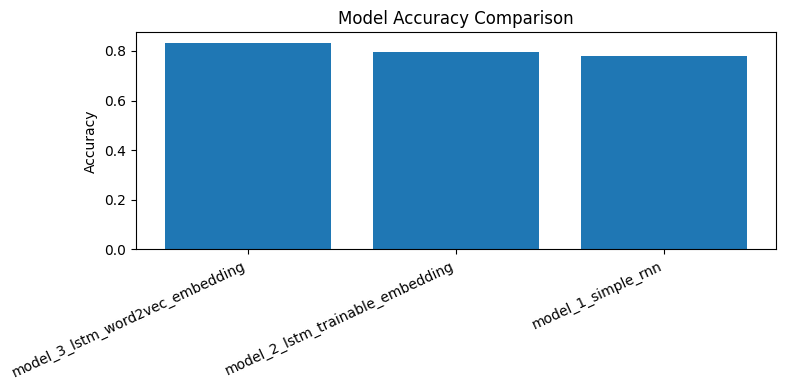

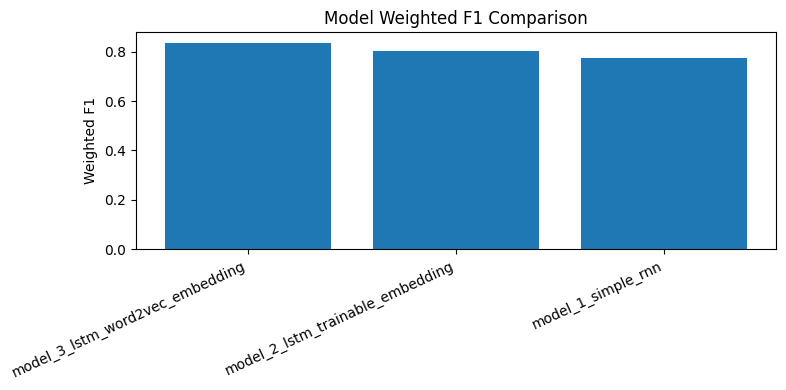

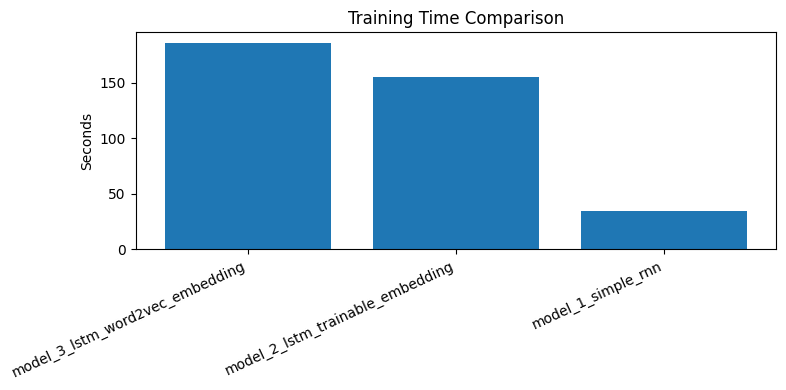

In [ ]:
comparison_df = pd.DataFrame([
    rnn_result,
    lstm_result,
    pretrained_result
])

comparison_df = comparison_df.sort_values(by="Weighted F1", ascending=False).reset_index(drop=True)
display(comparison_df)

comparison_df.to_csv(os.path.join(RESULTS_DIR, "final_model_comparison.csv"), index=False)

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_accuracy_comparison.png"), dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Weighted F1"])
plt.title("Model Weighted F1 Comparison")
plt.ylabel("Weighted F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_f1_comparison.png"), dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_training_time_comparison.png"), dpi=150)
plt.show()

## Cell 27: Select Best Model

The best model is selected using weighted F1-score because the dataset has class imbalance.

In [ ]:


# The best model is selected based on weighted F1-score from the comparison table.
best_model_name = comparison_df.loc[0, "Model"]

print("Best model based on weighted F1-score:", best_model_name)

# Dictionary linking model names with trained model objects
model_lookup = {
    "model_1_simple_rnn": rnn_model,
    "model_2_lstm_trainable_embedding": lstm_model,
    "model_3_lstm_word2vec_embedding": pretrained_lstm_model
}

# Dictionary linking model names with their prediction arrays
prediction_lookup = {
    "model_1_simple_rnn": rnn_predictions,
    "model_2_lstm_trainable_embedding": lstm_predictions,
    "model_3_lstm_word2vec_embedding": pretrained_predictions
}

best_model = model_lookup[best_model_name]
best_predictions = prediction_lookup[best_model_name]

print("Best model selected successfully.")

Best model based on weighted F1-score: model_3_lstm_word2vec_embedding
Best model selected successfully.


## Cell 28: Error Analysis

This section displays misclassified headlines.  
It helps identify where the model gets confused and why errors may happen.

In [ ]:
test_results = pd.DataFrame({
    "clean_text": X_test_text,
    "actual_label": label_encoder.inverse_transform(y_test),
    "predicted_label": label_encoder.inverse_transform(best_predictions)
})

misclassified = test_results[test_results["actual_label"] != test_results["predicted_label"]].copy()

print("Total test samples:", len(test_results))
print("Number of wrong predictions:", len(misclassified))
print("Error rate:", len(misclassified) / len(test_results))

display(misclassified.head(10))

misclassified.head(25).to_csv(
    os.path.join(RESULTS_DIR, "misclassified_examples.csv"),
    index=False
)

print("\nThree example errors:")
for _, row in misclassified.head(3).iterrows():
    print("-" * 80)
    print("Text      :", row["clean_text"])
    print("Actual    :", row["actual_label"])
    print("Predicted :", row["predicted_label"])

Total test samples: 2190
Number of wrong predictions: 365
Error rate: 0.16666666666666666


,clean_text,actual_label,predicted_label
0,student debt level often higher state school e...,MONEY,EDUCATION
10,self driving car may coming sooner thought,TECH,MONEY
12,adventure creationist field museum,EDUCATION,CULTURE & ARTS
19,ripping,MONEY,CULTURE & ARTS
24,broken system created ferguson educating peopl...,EDUCATION,TECH
32,delorean not fly drive,TECH,MONEY
49,baylor victim family member horrified push art...,SPORTS,CULTURE & ARTS
54,vintage japanese travel poster spark urge trav...,CULTURE & ARTS,TECH
55,conversation friend prostitute,MONEY,TECH
71,ronda rousey eerily predicted would lose,SPORTS,TECH



Three example errors:
--------------------------------------------------------------------------------
Text      : student debt level often higher state school elite private college analysis show
Actual    : MONEY
Predicted : EDUCATION
--------------------------------------------------------------------------------
Text      : self driving car may coming sooner thought
Actual    : TECH
Predicted : MONEY
--------------------------------------------------------------------------------
Text      : adventure creationist field museum
Actual    : EDUCATION
Predicted : CULTURE & ARTS


## Cell 29: Model Complexity vs Performance Discussion

The Simple RNN is the lightest model and usually trains faster, but it has limited ability to remember useful context from text sequences.  
The LSTM model is more complex, but it generally performs better because it uses gates to control which information should be remembered or forgotten.  
The pretrained embedding LSTM adds external word knowledge, so it can generalize better when the dataset is not very large.  

A common trade-off is that stronger models may take longer to train. In this task, weighted F1-score is more useful than accuracy alone because the class distribution is not perfectly balanced. Misclassification can happen when headlines are short, when one headline contains words related to more than one category, or when categories have overlapping meaning.

## Cell 30: Save Final Model, Tokenizer, and Label Encoder

Saving these files allows the model to be reused later for prediction without retraining.

In [ ]:
best_model.save(os.path.join(RESULTS_DIR, "best_task3_nlp_model.keras"))

with open(os.path.join(RESULTS_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

with open(os.path.join(RESULTS_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

final_summary = f'''
Final NLP Model Summary

Dataset task: News headline category classification
Number of classes: {num_classes}
Best model: {best_model_name}

Model comparison:
{comparison_df.to_string(index=False)}

The best model was selected using weighted F1-score because the dataset contains class imbalance.
'''

with open(os.path.join(RESULTS_DIR, "final_summary.txt"), "w") as f:
    f.write(final_summary)

print(final_summary)
print("Saved files inside:", RESULTS_DIR)


Final NLP Model Summary

Dataset task: News headline category classification
Number of classes: 5
Best model: model_3_lstm_word2vec_embedding

Model comparison:
                           Model  Accuracy  Precision   Recall  Weighted F1  Training Time (seconds)
 model_3_lstm_word2vec_embedding  0.833333   0.843111 0.833333     0.836586               186.194288
model_2_lstm_trainable_embedding  0.797260   0.834085 0.797260     0.801040               155.453630
              model_1_simple_rnn  0.777626   0.796196 0.777626     0.775842                34.364016

The best model was selected using weighted F1-score because the dataset contains class imbalance.

Saved files inside: task3_nlp_outputs


## Cell 31: Real-Time Prediction Function

This function cleans new text, applies the same tokenizer and padding, and returns the predicted category with confidence.

In [ ]:
def predict_news_category(text):
    cleaned = clean_headline(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    probabilities = best_model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    confidence = float(probabilities[predicted_index])

    return {
        "cleaned_text": cleaned,
        "predicted_category": predicted_label,
        "confidence": confidence
    }


sample_text = "Apple announces new artificial intelligence features for iPhone users"
predict_news_category(sample_text)

{'cleaned_text': 'apple announces new artificial intelligence feature iphone user',
 'predicted_category': 'TECH',
 'confidence': 0.9985637068748474}

## Cell 32: Simple Gradio Interface

This is a basic GUI for real-time prediction.  


In [ ]:
import gradio as gr

def gradio_predict(text):
    result = predict_news_category(text)
    return (
        result["predicted_category"],
        round(result["confidence"], 4),
        result["cleaned_text"]
    )

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, placeholder="Enter a news headline here..."),
    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Number(label="Confidence"),
        gr.Textbox(label="Cleaned Text")
    ],
    title="News Headline Category Predictor",
    description="This interface predicts the category of a news headline using the best trained NLP model."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Cell 33: Final Conclusion

This notebook completed the required NLP pipeline for text classification.  
The work included text cleaning, tokenization, sequence padding, three recurrent deep learning models, training curves, confusion matrices, classification reports, error analysis, model comparison, and real-time prediction.

The LSTM-based models are expected to perform better than the Simple RNN because they handle sequence information more effectively.  
The pretrained embedding model can improve performance further because it uses word representations learned from a larger external corpus.